In [49]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn

In [50]:
from collections import Counter

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

from utils.constants import *

In [51]:
df = pd.read_csv("../data/3_gold/dataset-processed-gb.csv")

categorical_features = list(CATEGORICAL_COLUMNS)

for col in categorical_features:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'low_risk' examples: 359346
Number of 'high_risk' examples: 252602

=== Fine Data ===
Number of 'alarm' examples: 228273
Number of 'severe' examples: 24329


In [52]:
params_coarse = {
    'max_iter': 1000, 
    'early_stopping': True, 
    'n_iter_no_change': 50,
    'tol': 1e-6,
    'max_depth': 6,
    'learning_rate': 0.05,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}
params_fine = {
    'max_iter': 1000, 
    'early_stopping': True, 
    'n_iter_no_change': 50,
    'tol': 1e-6,
    'max_depth': 9,
    'learning_rate': 0.03,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}


def get_hgb_models():
    model_coarse = HistGradientBoostingClassifier(**params_coarse)
    model_fine = HistGradientBoostingClassifier(**params_fine)
    return model_coarse, model_fine


def resample_fine(X, y):
    class_counts = Counter(y)    
    pipeline = Pipeline([
        # ('under', RandomUnderSampler(sampling_strategy={0: max(class_counts[1], class_counts[0] // 2)}, random_state=RANDOM_STATE)),
        ('over', SMOTE(sampling_strategy={1: max(class_counts[1], class_counts[0] // 3)}, random_state=RANDOM_STATE))
    ])
    return pipeline.fit_resample(X, y)


def eval_hierarchical(
    model_coarse, model_fine, X_val, y_val, 
    threshold_coarse=0.4, threshold_fine=0.4
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X_val)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X_val.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y_val, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y_val, final_preds, average='macro'), final_preds


def predict_soft_cascade(model_coarse, model_fine, X, y):
    # Get Probabilities from Coarse
    probs_coarse = model_coarse.predict_proba(X)
    preds_coarse = (probs_coarse >= 0.4).astype(int)[:, 1]
    p_high_risk = (probs_coarse[:, 1] + 0.1).clip(0.0, 1.0)
    
    # Get Probabilities from Fine
    probs_fine = model_fine.predict_proba(X) 
    p_severe_given_high = (probs_fine[:, 1] + 0.1 * preds_coarse).clip(0.0, 1.0) # P(Severe | High)
        
    # P(Severe) = P(High) * P(Severe | High)
    p_severe_global = p_high_risk * p_severe_given_high
    
    # P(Alarm) = P(High) * (1 - P(Severe | High))
    p_alarm_global = p_high_risk * (1 - p_severe_given_high)
    
    # P(Low) = 1 - P(High)
    p_low_global = 1.0 - p_high_risk
    
    final_probs = np.vstack([p_low_global, p_alarm_global, p_severe_global]).T
    final_preds = np.argmax(final_probs, axis=1)

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds


def train_hierarchical_hgb(X_coarse, y_coarse, X_fine, y_fine):
    X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
        X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
    )
    X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
        X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
    )
    
    model_coarse, model_fine = get_hgb_models()

    print("Training Coarse Model...")
    model_coarse.fit(
        X_train_coarse, y_train_coarse,
        X_val=X_val_coarse, y_val=y_val_coarse
    )

    X_train_fine, y_train_fine = resample_fine(X_train_fine, y_train_fine)

    print("Training Fine Model...")
    model_fine.fit(
        X_train_fine, y_train_fine,
        X_val=X_val_fine, y_val=y_val_fine
    )
    
    return model_coarse, model_fine

In [53]:
model_coarse, model_fine = train_hierarchical_hgb(X_coarse, y_coarse, X_fine, y_fine)

Training Coarse Model...
Training Fine Model...


In [54]:
calibrated_coarse = CalibratedClassifierCV(model_coarse, method='isotonic', cv='prefit')
calibrated_fine = CalibratedClassifierCV(model_fine, method='isotonic', cv='prefit')

X_fine_resampled, y_fine_resampled = resample_fine(X_fine, y_fine)

calibrated_coarse.fit(X_coarse, y_coarse)
calibrated_fine.fit(X_fine_resampled, y_fine_resampled)

/home/gabriel/Documents/UFRGS/SBCAS/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/home/gabriel/Documents/UFRGS/SBCAS/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,"HistGradientB...42, tol=1e-06)"
,method,'isotonic'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,loss,'log_loss'
,learning_rate,0.03
,max_iter,1000
,max_leaf_nodes,31
,max_depth,9
,min_samples_leaf,20


In [55]:
! pip install matplotlib

              precision    recall  f1-score   support

    Low Risk       0.80      0.82      0.81     63414
       Alarm       0.67      0.63      0.65     40283
      Severe       0.25      0.25      0.25      4294

    accuracy                           0.73    107991
   macro avg       0.57      0.57      0.57    107991
weighted avg       0.73      0.73      0.73    107991



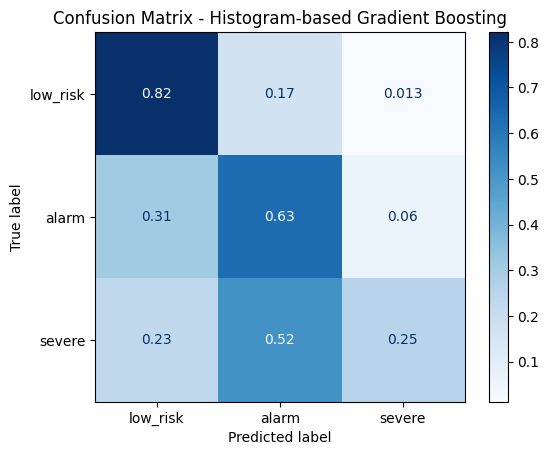

In [56]:
# Plot confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

f1, preds = predict_soft_cascade(
    calibrated_coarse, calibrated_fine, X_test, y_test
)

ConfusionMatrixDisplay.from_predictions(
    y_test, preds, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting")
plt.show()